<font color = 'red' > *La otra versión de cambio de clase no está bien enfocada.* </font>

#**BUILDING A MODEL TO PREDICT POSSIBLE CLASS SWITCHING**

In [ ]:
import pandas as pd
import numpy as np

##**1. Data ingestion and cleaning**

In [ ]:
df1=pd.read_csv('paradigma1.csv')

In [ ]:
df0=pd.read_csv('paradigma0.csv')

##Filtering

In [ ]:
df1=df1[['Epitope - Name']]

In [ ]:
df1[['Class Switching']] = 1

In [ ]:
len(df1)

67592

In [ ]:
df0=df0[['Epitope - Name']]

In [ ]:
df0[['Class Switching']] = 0

In [ ]:
len(df0)

23694

In [ ]:
import re
#Arbitrariamente se construye una función para delimitar la longitud de un epítopo entre 5 y 20 elementos

def is_valid_epitope(seq):
    if isinstance(seq, str):
        return 5 <= len(seq) <= 20 and bool(re.fullmatch(r'[A-Z]+', seq))
    return False

# Apply
df0filt = df0[df0['Epitope - Name'].apply(is_valid_epitope)]

# head
print("Filtered DataFrame head:")
print(df0filt.head())

# Longitud diferencial
print("\nOriginal DataFrame length:", len(df0))
print("Filtered DataFrame length:", len(df0filt))

Filtered DataFrame head:
  Epitope - Name  Class Switching
0       AALLQSAR                0
1       ACSFSSIP                0
2       ADALLEKG                0
3       ADYHRVMY                0
4        AEENVEH                0

Original DataFrame length: 23694
Filtered DataFrame length: 23501


In [ ]:
import re

def is_valid_epitope(seq):
    if isinstance(seq, str):
        return 5 <= len(seq) <= 20 and bool(re.fullmatch(r'[A-Z]+', seq))
    return False

# Apply el filtro
df1filt = df1[df1['Epitope - Name'].apply(is_valid_epitope)]

# A ver
print("Filtered DataFrame head:")
print(df1filt.head())

# Muestra la longitud
print("\nOriginal DataFrame length:", len(df1))
print("Filtered DataFrame length:", len(df1filt))

Filtered DataFrame head:
     Epitope - Name  Class Switching
0            AAAGDK                1
1           AAARTTS                1
2  AAASAIQGNVTSIHSL                1
3            AACRAA                1
4    AADAILHTPGCVPC                1

Original DataFrame length: 67592
Filtered DataFrame length: 64245


In [ ]:
#Función para limpiar epítopos de PTMs para tener más ejemplos
def clean_sequence(seq):
    if isinstance(seq, str):
        return seq.split('+')[0]
    return seq

# Apply
df0filt['Epitope - Name'] = df0filt['Epitope - Name'].apply(clean_sequence)
df1filt['Epitope - Name'] = df1filt['Epitope - Name'].apply(clean_sequence)

#Head
print("Cleaned df0filt head:")
print(df0filt.head())

print("\nCleaned df1filt head:")
print(df1filt.head())

# Longitud diferencial
print("\nCleaned df0filt length:", len(df0filt))
print("Cleaned df1filt length:", len(df1filt))

Cleaned df0filt head:
  Epitope - Name  Class Switching
0       AALLQSAR                0
1       ACSFSSIP                0
2       ADALLEKG                0
3       ADYHRVMY                0
4        AEENVEH                0

Cleaned df1filt head:
     Epitope - Name  Class Switching
0            AAAGDK                1
1           AAARTTS                1
2  AAASAIQGNVTSIHSL                1
3            AACRAA                1
4    AADAILHTPGCVPC                1

Cleaned df0filt length: 23501
Cleaned df1filt length: 64245


/tmp/ipykernel_319/4241660161.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df0filt['Epitope - Name'] = df0filt['Epitope - Name'].apply(clean_sequence)
/tmp/ipykernel_319/4241660161.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1filt['Epitope - Name'] = df1filt['Epitope - Name'].apply(clean_sequence)


In [ ]:
df1filt.to_csv('df1filt.csv')

In [ ]:
df0filt.to_csv('df0filt.csv')

###**Clean data**

In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.9 MB/s eta 0:00:00


In [ ]:
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq



In [ ]:
#Código para crear un fasta sin mucha info
records = []

for i, seq in enumerate(df0filt["Epitope - Name"]):
    if isinstance(seq, str):
        records.append(SeqRecord(Seq(seq), id=f"seq_{i}", description=""))

SeqIO.write(records, "df0filt.fasta", "fasta")

23501

In [ ]:
records = []

for i, seq in enumerate(df1filt["Epitope - Name"]):
    if isinstance(seq, str):
        records.append(SeqRecord(Seq(seq), id=f"seq_{i}", description=""))

SeqIO.write(records, "df1filt.fasta", "fasta")

64245

Para eliminar potenciales secuencias similares o parecidas con un umbral de 0.9 se usa el software CD-HIT en la terminal con el siguiente código

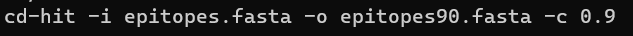

In [ ]:
import pandas as pd
from Bio import SeqIO

records = []
for rec in SeqIO.parse("0filt90.fasta", "fasta"):
    records.append({
        "id": rec.id,
        "description": rec.description,
        "sequence": str(rec.seq)
    })

df0 = pd.DataFrame(records)
print(df0.head())


       id description              sequence
0   seq_7       seq_7       AFVVFLLVTLAILTA
1   seq_8       seq_8  AGAGGGAGGAGAGGGAGGAG
2  seq_10      seq_10       AIGIITLYLGAVVQA
3  seq_17      seq_17          ATEKSNVVRGWV
4  seq_20      seq_20       AVSLDFSPGTSGSPI


In [ ]:
df0= df0[['sequence']]

In [ ]:
type(df0)

pandas.core.frame.DataFrame

In [ ]:
df0['Class Switching'] = 0

In [ ]:
df0.head()

,sequence,Class Switching
0,AFVVFLLVTLAILTA,0
1,AGAGGGAGGAGAGGGAGGAG,0
2,AIGIITLYLGAVVQA,0
3,ATEKSNVVRGWV,0
4,AVSLDFSPGTSGSPI,0


In [ ]:
records = []
for rec in SeqIO.parse("1filt90.fasta", "fasta"):
    records.append({
        "id": rec.id,
        "description": rec.description,
        "sequence": str(rec.seq)
    })

df1 = pd.DataFrame(records)
print(df1.head())

      id description             sequence
0  seq_2       seq_2     AAASAIQGNVTSIHSL
1  seq_4       seq_4       AADAILHTPGCVPC
2  seq_5       seq_5       AADMIMHTPGCVPC
3  seq_6       seq_6  AAEESKLPINPLSNSLLRH
4  seq_7       seq_7      AAGTAAQAAVVRFQE


In [ ]:
df1= df1[['sequence']]

In [ ]:
df1['Class Switching'] = 1

In [ ]:
clean= pd.concat([df0, df1])

In [ ]:
clean.to_csv('cleanPARADIGMAafterCD-HIT.csv')

In [ ]:
clean= pd.read_csv('cleanPARADIGMAafterCD-HIT.csv',index_col=0)

In [ ]:
clean.head()

,sequence,Class Switching
0,AFVVFLLVTLAILTA,0
1,AGAGGGAGGAGAGGGAGGAG,0
2,AIGIITLYLGAVVQA,0
3,ATEKSNVVRGWV,0
4,AVSLDFSPGTSGSPI,0


In [ ]:
print('La longitud actual es:',len(clean))
print('La longitud tras borrar duplicados es', len(clean.drop_duplicates()))

La longitud actual es: 54272
La longitud tras borrar duplicados es 54272


### Sampling
It's helpful to do it now, because it consists of a way to save resources

In [ ]:
clean['Class Switching'].value_counts()

,count
Class Switching,
1,37011
0,17261


In [ ]:
balanced_df = clean.groupby('Class Switching').sample(n=15000, random_state=11).reset_index(drop=True)


In [ ]:
balanced_df.to_csv('paradigmaFEATURE-EXTRACTION.csv',index=False)

##**FEATURE EXTRACTION**

In [ ]:
import pandas as pd
going_under=pd.read_csv('paradigmaFEATURE-EXTRACTION.csv')

In [ ]:
pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 30.8 MB/s eta 0:00:00


### BIOCHEMISTRY

In [ ]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis


#  Función para calcular descriptores globales de una secuencia
def extract_global_descriptors(seq):
    try:
        seq = str(seq).replace(" ", "").upper()
        analysis = ProteinAnalysis(seq)
        return pd.Series({
            "length": len(seq),
            "molecular_weight": analysis.molecular_weight(),
            "aromaticity": analysis.aromaticity(),
            "instability_index": analysis.instability_index(),
            "isoelectric_point": analysis.isoelectric_point(),
            "gravy": analysis.gravy()
        })
    except Exception as e:
        # Si hay caracteres no válidos o secuencia vacía
        return pd.Series({
            "length": None,
            "molecular_weight": None,
            "aromaticity": None,
            "instability_index": None,
            "isoelectric_point": None,
            "gravy": None
        })

features_df = going_under["sequence"].apply(extract_global_descriptors)

In [ ]:
going_under.columns

Index(['sequence', 'Class Switching'], dtype='object')

In [ ]:
going_under = pd.concat([going_under, features_df], axis=1)

In [ ]:
going_under.head()

,sequence,Class Switching,length,molecular_weight,aromaticity,instability_index,isoelectric_point,gravy
0,SSNGSNDVWIFN,0,12.0,1339.3660,0.166667,12.691667,4.050028,-0.516667
1,HGTCERSEAGIC,0,12.0,1262.3734,0.000000,39.041667,5.398874,-0.475000
2,SGVEGEGLHRLGYIL,0,15.0,1599.7854,0.066667,11.486667,5.376253,0.113333
3,ASGYVAASAVNV,0,12.0,1108.2016,0.083333,2.091667,5.569164,1.083333
4,AGSVYTNSCLVA,0,12.0,1184.3192,0.083333,26.500000,5.560752,0.900000


In [ ]:
going_under.columns

Index(['sequence', 'Class Switching', 'length', 'molecular_weight',
       'aromaticity', 'instability_index', 'isoelectric_point', 'gravy'],
      dtype='object')

In [ ]:
going_under.isna().sum()

,0
sequence,0
Class Switching,0
length,10
molecular_weight,10
aromaticity,10
instability_index,10
isoelectric_point,10
gravy,10


In [ ]:
print(len(going_under))
len(going_under.dropna())

30000


29990

In [ ]:
going_under= going_under.dropna()

In [ ]:
len(going_under)

29990

In [ ]:
biofeatures= going_under

In [ ]:
biofeatures.head()

,sequence,Class Switching,length,molecular_weight,aromaticity,instability_index,isoelectric_point,gravy
0,SSNGSNDVWIFN,0,12.0,1339.3660,0.166667,12.691667,4.050028,-0.516667
1,HGTCERSEAGIC,0,12.0,1262.3734,0.000000,39.041667,5.398874,-0.475000
2,SGVEGEGLHRLGYIL,0,15.0,1599.7854,0.066667,11.486667,5.376253,0.113333
3,ASGYVAASAVNV,0,12.0,1108.2016,0.083333,2.091667,5.569164,1.083333
4,AGSVYTNSCLVA,0,12.0,1184.3192,0.083333,26.500000,5.560752,0.900000


### ATRIBUTOS FÍSICOS

In [ ]:
import pandas as pd
import itertools


#Configuración
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")  # Los 20 aminoácidos estándar

# Función para composición de aminoácidos
def amino_acid_composition(seq):
    seq = seq.upper()
    length = len(seq)
    counts = {aa: seq.count(aa) / length for aa in amino_acids}
    return counts

# Función para composición de dipéptidos
def dipeptide_composition(seq):
    seq = seq.upper()
    length = len(seq) - 1
    dipeptides = [''.join(p) for p in itertools.product(amino_acids, repeat=2)]
    counts = {dp: 0 for dp in dipeptides}
    for i in range(len(seq) - 1):
        dp = seq[i:i+2]
        if dp in counts:
            counts[dp] += 1
    if length > 0:
        counts = {k: v / length for k, v in counts.items()}
    return counts

In [ ]:
# Extraer atributos
aac_features = going_under["sequence"].apply(amino_acid_composition).apply(pd.Series)

In [ ]:
aac_features.isna().sum()

,0
A,0
C,0
D,0
E,0
F,0
G,0
H,0
I,0
K,0
L,0


In [ ]:
aac_features.head()

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
0,0.000000,0.000000,0.083333,0.000000,0.083333,0.083333,0.000000,0.083333,0.0,0.000000,0.0,0.250000,0.0,0.0,0.000000,0.250000,0.000000,0.083333,0.083333,0.000000
1,0.083333,0.166667,0.000000,0.166667,0.000000,0.166667,0.083333,0.083333,0.0,0.000000,0.0,0.000000,0.0,0.0,0.083333,0.083333,0.083333,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.133333,0.000000,0.266667,0.066667,0.066667,0.0,0.200000,0.0,0.000000,0.0,0.0,0.066667,0.066667,0.000000,0.066667,0.000000,0.066667
3,0.333333,0.000000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.0,0.000000,0.0,0.083333,0.0,0.0,0.000000,0.166667,0.000000,0.250000,0.000000,0.083333
4,0.166667,0.083333,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.0,0.083333,0.0,0.083333,0.0,0.0,0.000000,0.166667,0.083333,0.166667,0.000000,0.083333


In [ ]:
dpc_features = going_under["sequence"].apply(dipeptide_composition).apply(pd.Series)


In [ ]:
dpc_features.isna().sum()

,0
AA,0
AC,0
AD,0
AE,0
AF,0
...,...
YS,0
YT,0
YV,0
YW,0


In [ ]:
features=pd.concat([biofeatures,aac_features,dpc_features],axis=1)

In [ ]:
features.head()

,sequence,Class Switching,length,molecular_weight,aromaticity,instability_index,isoelectric_point,gravy,A,C,...,YM,YN,YP,YQ,YR,YS,YT,YV,YW,YY
0,SSNGSNDVWIFN,0,12.0,1339.3660,0.166667,12.691667,4.050028,-0.516667,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
1,HGTCERSEAGIC,0,12.0,1262.3734,0.000000,39.041667,5.398874,-0.475000,0.083333,0.166667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
2,SGVEGEGLHRLGYIL,0,15.0,1599.7854,0.066667,11.486667,5.376253,0.113333,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
3,ASGYVAASAVNV,0,12.0,1108.2016,0.083333,2.091667,5.569164,1.083333,0.333333,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.090909,0.0,0.0
4,AGSVYTNSCLVA,0,12.0,1184.3192,0.083333,26.500000,5.560752,0.900000,0.166667,0.083333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.090909,0.000000,0.0,0.0


In [ ]:
features['Class Switching'].value_counts()

,count
Class Switching,
0,15000
1,14990


In [ ]:
balanced_df = features.groupby('Class Switching').sample(n=14900, random_state=11).reset_index(drop=True)


In [ ]:
balanced_df['Class Switching'].value_counts()

,count
Class Switching,
0,14900
1,14900


In [ ]:
balanced_df.to_csv('paradigmaFEATURES-to-predict.csv',index=False) #Checkpoint

##**ENTRENAMIENTO DEL MODELO, ESCALADO + PCA EN DATOS DE ENTRENAMIENTO PARA EVITAR DATA LEAKAGE**

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [ ]:
balanced_df=pd.read_csv('paradigmaFEATURES-to-predict.csv')

In [ ]:
X_bp=balanced_df.drop(columns=['sequence','Class Switching'])
y_bp=balanced_df['Class Switching']

In [ ]:
X_train_BP, X_test_BP, y_train_BP, y_test_BP = train_test_split(X_bp, y_bp, test_size=0.2, random_state=55)

Datos crudos sin escalar y sin PCA

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
clf = RandomForestClassifier(
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=500,
    random_state=19,
    class_weight="balanced"
)

In [ ]:
clf.fit(X_train_BP, y_train_BP)

RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=19)

In [ ]:
y_pred = clf.predict(X_test_BP)

print("Accuracy:", accuracy_score(y_test_BP, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test_BP, y_pred))

Accuracy: 0.6904362416107382

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.67      0.78      0.72      3025
           1       0.72      0.60      0.66      2935

    accuracy                           0.69      5960
   macro avg       0.70      0.69      0.69      5960
weighted avg       0.69      0.69      0.69      5960



Datos escalados

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train_BP)


Datos escalados + PCA

In [ ]:
pca_model= PCA(n_components=0.95)
x_pca_scaled= pca_model.fit_transform(x_train_scaled)

Datos sin escalar + PCA

In [ ]:
x_pca_noscaled= pca_model.fit_transform(X_train_BP)

## **Construyendo un modelo con RANDOM FOREST**

Modelo sin escalado y sin PCA

### Modelo con escalado sin usar dimensionality reduction

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
clf = RandomForestClassifier(
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=500,
    random_state=19,
    class_weight="balanced"
)

In [ ]:
clf.fit(x_train_scaled, y_train_BP)

RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=19)

In [ ]:
y_pred = clf.predict(X_test_BP)

print("Accuracy:", accuracy_score(y_test_BP, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test_BP, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Accuracy: 0.49689813888333

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      2514
           1       0.50      1.00      0.66      2483

    accuracy                           0.50      4997
   macro avg       0.25      0.50      0.33      4997
weighted avg       0.25      0.50      0.33      4997



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Modelo con PCA pero sin escalar

In [ ]:
clf = RandomForestClassifier(
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=500,
    random_state=55,
    class_weight="balanced"
)

In [ ]:
clf.fit(x_pca_noscaled, y_train_BP)

RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=55)

In [ ]:
y_pred = clf.predict(pca_model.transform(X_test_BP))

print("Accuracy:", accuracy_score(y_test_BP, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test_BP, y_pred))

Accuracy: 0.647388433059836

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.65      0.65      0.65      2514
           1       0.65      0.64      0.64      2483

    accuracy                           0.65      4997
   macro avg       0.65      0.65      0.65      4997
weighted avg       0.65      0.65      0.65      4997



###Modelo con PCA y con escalado

In [ ]:
clf.fit(x_pca_scaled, y_train_BP)

RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=55)

In [ ]:
y_pred = clf.predict(X_test_BP)

print("Accuracy:", accuracy_score(y_test_BP, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test_BP, y_pred))

Accuracy: 0.7702621572943766

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.72      0.88      0.79      2514
           1       0.84      0.66      0.74      2483

    accuracy                           0.77      4997
   macro avg       0.78      0.77      0.77      4997
weighted avg       0.78      0.77      0.77      4997



In [ ]:
import joblib

joblib.dump(clf, 'modelo_CS.pkl')

['modelo_CS.pkl']

Dado que es en esta estrategia de clasificación donde se obtienen mejores scores es útil usar un ajuste de hiperparámetros

### Ajuste de hiperparámetros con el mejor modelo de RF





## Construyendo un modelo con Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split

nb_model=GaussianNB()


In [ ]:
nb_model.fit(x_train_scaled, y_train_BP)

GaussianNB()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = nb_model.predict(X_test_BP)

print("Accuracy:", accuracy_score(y_test_BP, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test_BP, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test_BP, y_pred))

Accuracy: 0.49689813888333

Matriz de confusión:
 [[   0 2514]
 [   0 2483]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      2514
           1       0.50      1.00      0.66      2483

    accuracy                           0.50      4997
   macro avg       0.25      0.50      0.33      4997
weighted avg       0.25      0.50      0.33      4997



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `

## **AUTOMATIZACIÓN**

Recibes una secuencia, consideremos que es un epítopo.
Se le extraen atributos, aac,dppc, bio-features
Escalado y PCA
Modelado

![][image1]

[image1]: <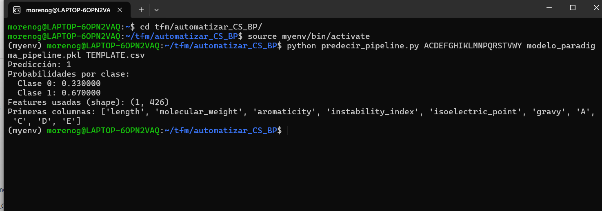>
Esta es la forma en la que el modelo se ejecuta por terminal, todos los documentos necesarios están disponibles en https://github.com/MorenogD.